<a href="https://colab.research.google.com/github/kerryjilak/TReND-CaMinA/blob/develop/notebooks/Kenya26/03-04-AllenTutorial/Session_3_Population_Decoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/AllenSWDB/TReND-CaMinA/blob/main/notebooks/Kenya26/03-04-AllenTutorial/Session_3_Population_Decoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
    <h1> How can we extract information from neural activity? </h1>
    <h2> Decoding with the Allen Brain Observatory </h2>

In this tutorial, we are going to explore decoding of stimulus informatin using data from the Allen Brain Observatory.  We will look at how we can decode stimulus information and ask questions about what doing so can tell us about neural responses.  
    
For the examples we provide we will look at the 'Drifting Gratings' stimulus.  You might consider a similar project that looks at another stimulus.

The Drifting Gratings stimulus consists of a sinusoidal grating that moves in 8 directions and at 5 temporal frequencies. Each stimulus condition (direction + temporal frequency combination) is repeated 15 times in random order. In addition, there are blanksweeps (when the grating is replaced with mean luminance gray) interleaved among the trials.

We will compute the mean response of a set of neurons to each of these stimulus conditions; this produces what is called a 'tuning curve'.  Then we will attempt to extract the stimulus condition that elicited a given response on a trial by trial basis.
</div>

In [1]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

### Standard imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# we're going to need lists of colors below
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.values())

Scikit-learn is the standard machine learning package in python.  You can import it with the command below.

In [2]:
import sklearn

### Allen Brain Observatory set up

This instantiates the tools in the Allen SDK that allow us to access the Brain Observatory data.

In [3]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [4]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "visual_coding_2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

For our examples, we're going to look at a particular session that we've chosen for you.  We are going to start by examining two specific cells that we have already identified.

We will grab the data for a session that includes the first cell we want to look at.

In [5]:
cell_id = 541513979

The following cell finds the session_id associated with the cell_id given above.

In [6]:
exps = boc.get_ophys_experiments(cell_specimen_ids=[541513979], stimuli=['drifting_gratings'])
session_id = exps[0]['id']

In [7]:
exps

[{'id': 540684467,
  'imaging_depth': 175,
  'targeted_structure': 'VISp',
  'cre_line': 'Emx1-IRES-Cre',
  'reporter_line': 'Ai93(TITL-GCaMP6f)',
  'acquisition_age_days': 120,
  'experiment_container_id': 536323956,
  'session_type': 'three_session_A',
  'donor_name': '252174',
  'specimen_name': 'Emx1-IRES-Cre;Camk2a-tTA;Ai93(MG)-252174',
  'fail_eye_tracking': False}]

In [8]:
session_id

540684467

The following cell returns the data for session 'session_id' and puts it into the 'data_set' object.

In [9]:
data_set = boc.get_ophys_experiment_data(session_id)

Within a session, cell's are indexed with contiguous integers (so they can all be referenced in an array).  The following code retrieves the index associated with the `cell_id`.

In [60]:
cell_index = data_set.get_cell_specimen_indices([cell_id])[0]

In [61]:
cell_index

6

<p>In order to compute the tuning curve of the neuron, we need to access

<li>the activity of the neuron.  We will use the DF/F trace
<li>stimulus information for the drifting grating stimulus


In [12]:
timestamps, dff = data_set.get_dff_traces()
stim_table = data_set.get_stimulus_table('drifting_gratings')

In [21]:
timestamps

array([  12.98567,   13.01884,   13.05201, ..., 3852.12818, 3852.16135,
       3852.19453])

In [22]:
dff

array([[0.2603065 , 0.26848692, 0.2537276 , ..., 0.4832628 , 0.562328  ,
        0.54916185],
       [0.12359576, 0.14682338, 0.16583093, ..., 0.13301598, 0.2175612 ,
        0.3015457 ],
       [0.15424512, 0.13349123, 0.18023464, ..., 0.14015312, 0.18902878,
        0.26112455],
       ...,
       [0.29815567, 0.16793533, 0.13316172, ..., 0.16471283, 0.20589736,
        0.2314399 ],
       [0.40963152, 0.5189302 , 0.48454905, ..., 0.12588076, 0.10504165,
        0.26602805],
       [0.09165223, 0.19570875, 0.17075698, ..., 0.349869  , 0.15585196,
        0.40525788]], dtype=float32)

In [14]:
stim_table

,temporal_frequency,orientation,blank_sweep,start,end
0,1.0,45.0,0.0,736,796
1,15.0,90.0,0.0,826,886
2,1.0,270.0,0.0,917,977
3,NaN,NaN,1.0,1007,1067
4,4.0,90.0,0.0,1098,1158
...,...,...,...,...,...
623,15.0,180.0,0.0,115063,115123
624,1.0,135.0,0.0,115153,115213
625,15.0,45.0,0.0,115244,115304
626,1.0,315.0,0.0,115334,115394


In [13]:
timestamps

array([  12.98567,   13.01884,   13.05201, ..., 3852.12818, 3852.16135,
       3852.19453])

It is always good to look at the data objects you're working with to make sure you understand what they are. What is the shape of the dff array?

In [15]:
dff.shape

(290, 115741)

This shape is [number of neurons, number of acquisition frames].

In [30]:
stim_table.shape

(628, 5)

In [16]:
num_neurons = dff.shape[0]

In [17]:
num_neurons

290

We need to create a **design matrix** for decoding.  This is a matrix of shape [trials, dimension].  In this case 'dimension' is the number of neurons we are going to use for decoding.  We will need to iterate through the `stim_table` to compute this.

As we saw last time, the `stim_table` looks like this:

In [18]:
stim_table.head(n=10)

,temporal_frequency,orientation,blank_sweep,start,end
0,1.0,45.0,0.0,736,796
1,15.0,90.0,0.0,826,886
2,1.0,270.0,0.0,917,977
3,NaN,NaN,1.0,1007,1067
4,4.0,90.0,0.0,1098,1158
5,1.0,270.0,0.0,1188,1248
6,2.0,135.0,0.0,1279,1339
7,4.0,270.0,0.0,1370,1429
8,4.0,45.0,0.0,1460,1520
9,4.0,0.0,0.0,1551,1610


For each presentation, we will need to compute the mean response between `start` to `end`.  We did this last time, but now we are doing this for every neuron in the data set simultaneously.

<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
**Quick reminder about pandas for our purposes today!**

To access data from a DataFrame we must specify the column we are using and specify the row using the index. To specify a column we can use two methods:

```stim_table['start']```

```stim_table.start```

Then to specify the row we want we must use the index of that row:

```stim_table['start'][0]```

```stim_table.start[0]```

We can also subselect portions of the DataFrame using the values in the DataFrame. For example, to select only the rows of the table where the orientation is 90 degrees we can use:

```stim_table[stim_table.orientation==90]```

Try this yourself. Note the index. The rows of this subselected DataFrame maintain the indices of the original DataFrame. Now in order to get a specific row, you either need to know it's original index, or use iloc. For example, this will return the first row of the subselected DataFrame regardless of the original index of that row:

```stim_table[stim_table.orientation==90].iloc[0]```
</div>

In [19]:
stim_table[stim_table.orientation==90].iloc[0]

,1
temporal_frequency,15.0
orientation,90.0
blank_sweep,0.0
start,826.0
end,886.0


In [20]:
stim_table[stim_table.orientation==90]

,temporal_frequency,orientation,blank_sweep,start,end
1,15.0,90.0,0.0,826,886
4,4.0,90.0,0.0,1098,1158
11,1.0,90.0,0.0,1732,1791
23,4.0,90.0,0.0,2818,2878
44,2.0,90.0,0.0,4719,4779
...,...,...,...,...,...
588,4.0,90.0,0.0,111895,111955
598,15.0,90.0,0.0,112800,112860
603,15.0,90.0,0.0,113253,113312
613,15.0,90.0,0.0,114158,114218


In [35]:
def compute_stim_and_response(dff, stim_table):

    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    activity = np.zeros([num_trials, num_neurons])
    stim_ori = []   # why are we using a list?
    stim_tf = []

    for i,row in stim_table.iterrows():
      activity[i] = dff[:,int(row.start):int(row.end)].mean(axis=1) #  compute the mean for *each* neuron
      if np.isfinite(row.orientation):
        stim_ori.append(str(row.orientation))
      else:
        stim_ori.append('blank')
      if np.isfinite(row.temporal_frequency):
        stim_tf.append(str(row.temporal_frequency))
      else:
        stim_tf.append('blank')


    stim_ori = np.array(stim_ori)
    stim_tf = np.array(stim_tf)

    return activity, stim_ori, stim_tf

NameError: name 'activity' is not defined

In [36]:
response, stim_ori, stim_tf = compute_stim_and_response(dff, stim_table)

In [43]:
response.shape

(628, 290)

In [29]:
np.unique(stim_ori)

array(['0.0', '135.0', '180.0', '225.0', '270.0', '315.0', '45.0', '90.0',
       'blank'], dtype='<U5')

Let's compute all the tuning curves quickly.

(This is essentially the same computation we did last time don't slightly differently, and for all the neurons simultaneously.)

In [38]:
def compute_dg_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]
    orientations = np.sort(stim_table.orientation.unique())
    orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']
    num_orientations = len(orientations)
    dg_tuning_curves = np.zeros([num_neurons, num_orientations-1])

    for i, ori in enumerate(orientations[:-1]):  # leave out nans
      mask = stim==str(ori)
      dg_tuning_curves[:,i] = response[mask,:].mean(axis=0)

    return dg_tuning_curves

In [39]:
dg_tuning_curves = compute_dg_tuning_curve(response, stim_ori, stim_table)

In the exercises, we'll use the temporal frequencies, so let's go ahead and compute the tuning curves for these here.

In [40]:
def compute_tf_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]
    temporal_frequencies = np.sort(stim_table.temporal_frequency.unique())
    # tf_labels = [str(tf) for tf in temporal_frequencies[:-1]] + ['blank']
    num_tfs = len(temporal_frequencies)
    tf_tuning_curves = np.zeros([num_neurons, num_tfs-1])

    for i, tf in enumerate(temporal_frequencies[:-1]):  # leave out nans
      mask = stim==str(tf)
      tf_tuning_curves[:,i] = response[mask,:].mean(axis=0)

    return tf_tuning_curves

In [41]:
tf_tuning_curves = compute_tf_tuning_curve(response, stim_tf, stim_table)

As a sanity check, let's take a look at the tuning curve for the cell we analyzed last time.

In [44]:
# we'll need the values of the orientations and temporal frequencies
orientations = np.sort(stim_table.orientation.unique())
temporal_frequencies = np.sort(stim_table.temporal_frequency.unique())

([<matplotlib.axis.XTick at 0x7880b8b3b020>,
 [Text(0.0, 0, '0'),
  Text(45.0, 0, '45'),
  Text(90.0, 0, '90'),
  Text(135.0, 0, '135'),
  Text(180.0, 0, '180'),
  Text(225.0, 0, '225'),
  Text(270.0, 0, '270'),
  Text(315.0, 0, '315')])

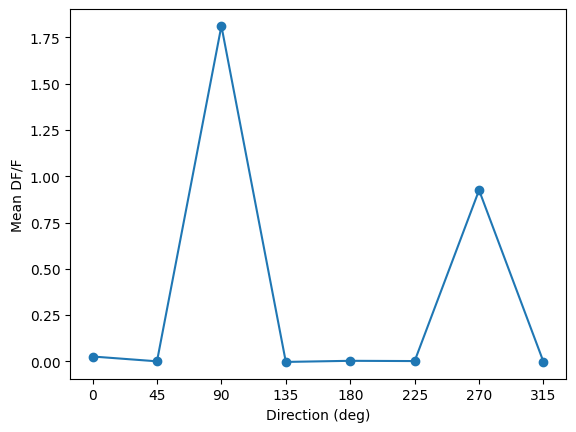

In [45]:
plt.plot(orientations[:-1], dg_tuning_curves[cell_index],'o-') # we are plotting for only one neuron out of the 290. so what we are doing is to analyse teh response as well as the mean df/f of only that cell, which is indexed already as cell number 6. so we can use the same function we have actually computed and built so far to calculate the mean fluourescence that that neuron has recorded over all the trials done on it.
plt.xlabel("Direction (deg)")
plt.ylabel("Mean DF/F")
plt.xticks(orientations[:-1])

**Exercise 1**:  Find another cell that responds well to this stimulus.

(Hint:  look at the maximum response for each neuron.)

In [46]:
max_response = np.max(dg_tuning_curves, axis=1)


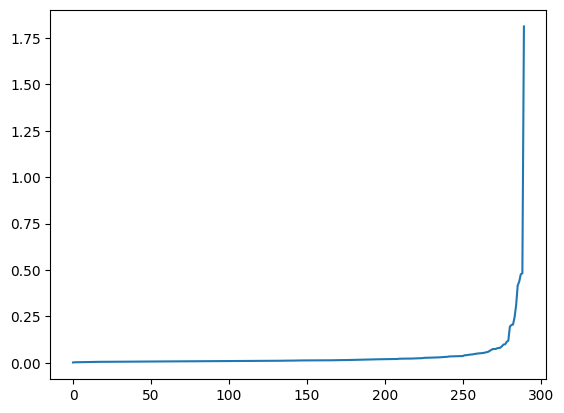

In [51]:
plt.plot(np.sort(max_response))

In [47]:
max_response

array([6.59455944e-03, 1.22214124e-02, 3.73844379e-03, 1.73203640e-02,
       6.94532490e-03, 1.00703453e-02, 1.81163622e+00, 3.56321977e-02,
       8.25328449e-03, 2.44782981e-01, 4.46880016e-02, 6.71937876e-03,
       2.22235910e-02, 1.07931937e-02, 5.16250970e-03, 1.28145715e-02,
       2.39609764e-03, 9.84927988e-03, 5.61662074e-02, 1.00223182e-02,
       3.60581822e-03, 3.09265702e-01, 1.22000457e-02, 5.93416918e-03,
       1.35399728e-02, 9.96451538e-03, 8.55167840e-03, 9.89798545e-03,
       2.32557880e-02, 6.95176448e-03, 7.55133842e-03, 7.34220935e-02,
       7.15670335e-03, 1.53796915e-02, 6.37785223e-03, 5.58592758e-03,
       2.93909550e-02, 3.18160463e-03, 8.83743424e-03, 8.55891782e-03,
       4.04376229e-02, 1.85518558e-02, 1.04050861e-02, 1.86779717e-02,
       7.35655700e-02, 3.09646248e-02, 1.94635092e-01, 4.77493409e-02,
       7.48933393e-03, 5.21500673e-02, 1.36799113e-02, 1.97984588e-02,
       1.60214821e-02, 3.53712314e-03, 6.73852938e-03, 1.26521144e-02,
      

Now let's look at another cell in this session

In [52]:
cell_index2 = 228

([<matplotlib.axis.XTick at 0x7880b8725ac0>,
 [Text(0.0, 0, '0'),
  Text(45.0, 0, '45'),
  Text(90.0, 0, '90'),
  Text(135.0, 0, '135'),
  Text(180.0, 0, '180'),
  Text(225.0, 0, '225'),
  Text(270.0, 0, '270'),
  Text(315.0, 0, '315')])

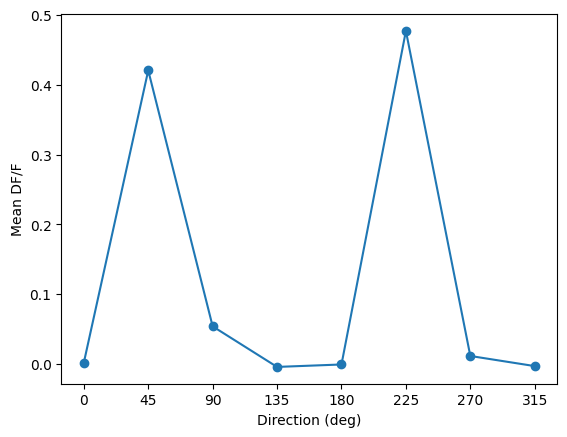

In [53]:
plt.plot(orientations[:-1], dg_tuning_curves[cell_index2],'o-')
plt.xlabel("Direction (deg)")
plt.ylabel("Mean DF/F")
plt.xticks(orientations[:-1]) # 9

We're going to start decoding by just looking at two cells.  Let's retrieve the activity of just those two cells

In [54]:
two_neuron_response = response[:,[cell_index,cell_index2]]

Text(0, 0.5, 'mean df/f cell index 228')

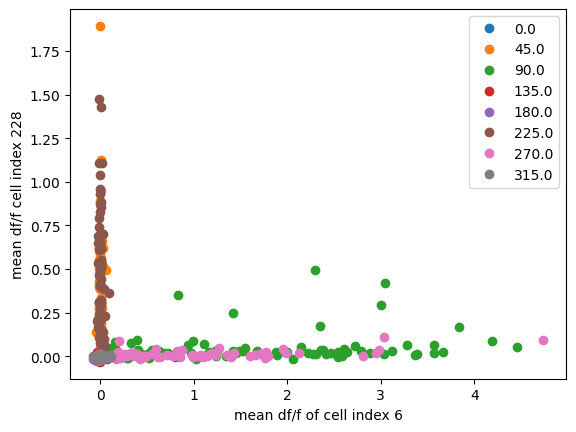

In [56]:
for i, ori in enumerate(orientations[:-1]):
  mask = stim_ori==str(ori)
  plt.plot(two_neuron_response[mask,0], two_neuron_response[mask,1],'o',color=colors[i], label=ori)
  plt.legend()
plt.xlabel('mean df/f of cell index '+str(cell_index))
plt.ylabel('mean df/f cell index '+str(cell_index2))

**Exercise 2**: Plot the temporal frequency tuning curves for these two cells.  Make a similar scatter plot of the trials of the two neurons with temporal frequency.

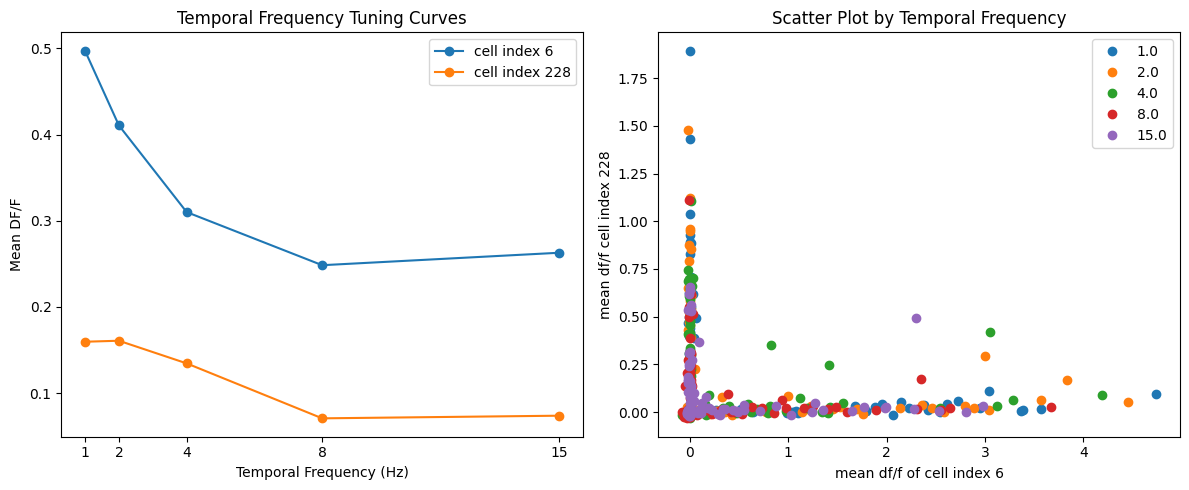

In [57]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(temporal_frequencies[:-1], tf_tuning_curves[cell_index], 'o-', label='cell index ' + str(cell_index))
plt.plot(temporal_frequencies[:-1], tf_tuning_curves[cell_index2], 'o-', label='cell index ' + str(cell_index2))
plt.xlabel("Temporal Frequency (Hz)")
plt.ylabel("Mean DF/F")
plt.xticks(temporal_frequencies[:-1])
plt.title("Temporal Frequency Tuning Curves")
plt.legend()

plt.subplot(1, 2, 2)
for i, tf in enumerate(temporal_frequencies[:-1]):
    mask = stim_tf == str(tf)
    plt.plot(two_neuron_response[mask, 0], two_neuron_response[mask, 1], 'o', color=colors[i], label=tf)
plt.xlabel('mean df/f of cell index ' + str(cell_index))
plt.ylabel('mean df/f cell index ' + str(cell_index2))
plt.title("Scatter Plot by Temporal Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In order to test our decoding models, we will need to set aside some data from testing, and use the rest for training.  (Why?)

For now, we are going to do this in a simple way, taking advantage of the fact that the stimulus presentations were randomized.  We will use the last quarter of the data for testing.  (Is this the best way?  Why might we *not* want to do this?)

In [77]:
stim_table.shape

(628, 5)

In [62]:
num_trials = stim_table.shape[0]
test_index = int(0.75*num_trials)

two_neuron_response_test = two_neuron_response[test_index:]
two_neuron_response_train = two_neuron_response[:test_index]

stim_ori_test = stim_ori[test_index:]
stim_ori_train = stim_ori[:test_index]

(two_neuron_response_test.shape, stim_ori_test.shape), (two_neuron_response_train.shape, stim_ori_train.shape)

(((157, 2), (157,)), ((471, 2), (471,)))

There are many classifiers in Scikit-learn.  We are going to use Linear Discriminant Analysis.

In [63]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

classifier_ori = LDA()
classifier_ori.fit(two_neuron_response_train, stim_ori_train)

LinearDiscriminantAnalysis()

How well did we do?

In [64]:
stim_ori_train_predicted = classifier_ori.predict(two_neuron_response_train)
stim_ori_test_predicted = classifier_ori.predict(two_neuron_response_test)

In [65]:
print("Percentage correct on training set:  ", np.mean(stim_ori_train_predicted == stim_ori_train))
print("Percentage correct on testing set:  ", np.mean(stim_ori_test_predicted == stim_ori_test))

Percentage correct on training set:   0.3333333333333333
Percentage correct on testing set:   0.2929936305732484


Only 30%!  

On one hand, the fact that the test and train performance are so close is a good sign.  It means the model has not *overfit*.

What's going on?  Let's plot where the decoder got it right and where is made mistakes.

In [66]:
def plot_test_performance(X, y, y_hat, xlabel=None, ylabel = None, names = None, ax = None):

    classes = np.unique(y)
    num_classes = len(classes)

    if ax is None:
        ax = plt.figure(figsize=(8,8)).gca()

    for ii,cl in enumerate(classes):
        if names is not None: # If 'names' was passed, use this for label
            this_label = names[ii]
        else:
            this_label = f'{cl}' # If 'names' was passed, otherwise use class number

        # Determine which points were correct (or not)
        is_class = y == cl
        is_correct = y == y_hat

        # Plot correctness with labels
        ax.scatter(X[is_class & is_correct,0],X[is_class & is_correct,1],c=colors[ii],edgecolor='none',label = this_label + ' correct')
        ax.scatter(X[is_class & ~is_correct,0],X[is_class & ~is_correct,1],c='none',edgecolor=colors[ii],label =this_label + ' incorrect')

    ax.set_xlim(X[:,0].min(),X[:,0].max())
    ax.set_ylim(X[:,1].min(),X[:,1].max())
    ax.set_xlabel(xlabel)# Optionally label axes
    ax.set_ylabel(ylabel)# Optionally label axes
    ax.legend()
    return ax

<Axes: xlabel='cell index 6', ylabel='cell index 228'>

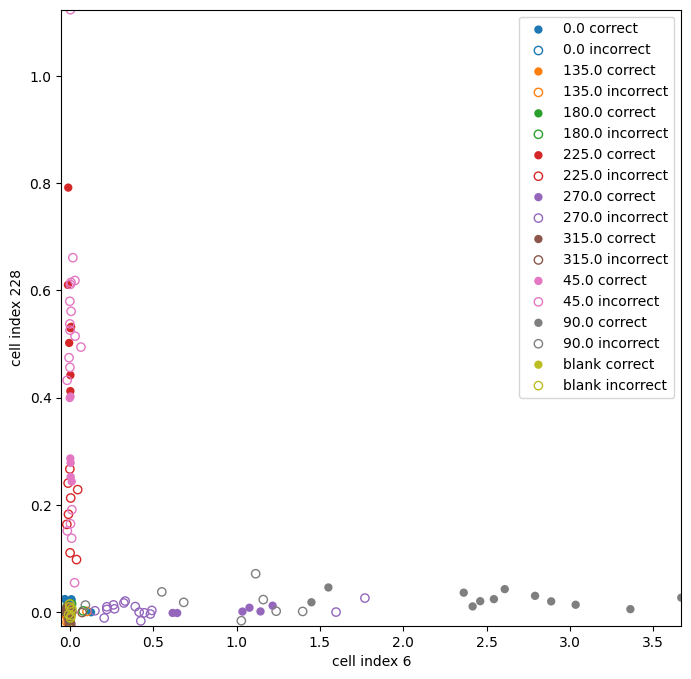

In [67]:
plot_test_performance(two_neuron_response_test, stim_ori_test, stim_ori_test_predicted, xlabel='cell index '+str(cell_index), ylabel='cell index '+str(cell_index2))

**Exercise 3**: Train a classifier to decode the temporal frequency of each trial and make a plot of the test performance.

Percentage correct on training set:   0.25477707006369427
Percentage correct on testing set:   0.1592356687898089


<Axes: xlabel='cell index 6', ylabel='cell index 228'>

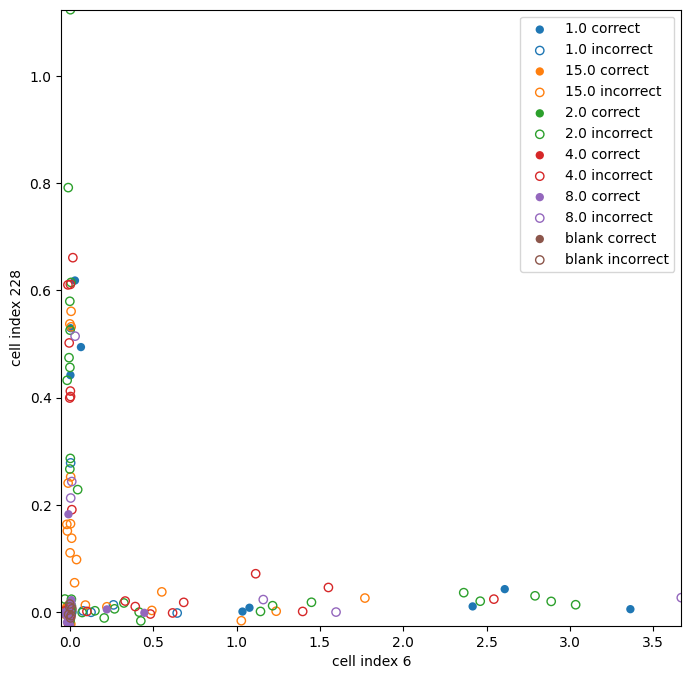

In [68]:
# you'll need the temporal frequencies for each of the training and test sets

stim_tf_test = stim_tf[test_index:]
stim_tf_train = stim_tf[:test_index]

classifier_tf = LDA()
classifier_tf.fit(two_neuron_response_train, stim_tf_train)

stim_tf_train_predicted = classifier_tf.predict(two_neuron_response_train)
stim_tf_test_predicted = classifier_tf.predict(two_neuron_response_test)

print("Percentage correct on training set:  ", np.mean(stim_tf_train_predicted == stim_tf_train))
print("Percentage correct on testing set:  ", np.mean(stim_tf_test_predicted == stim_tf_test))

plot_test_performance(two_neuron_response_test, stim_tf_test, stim_tf_test_predicted, xlabel='cell index '+str(cell_index), ylabel='cell index '+str(cell_index2))

The Confusion Matrix tells us what kinds of mistakes the classifier is making.

In [69]:
from sklearn.metrics import confusion_matrix

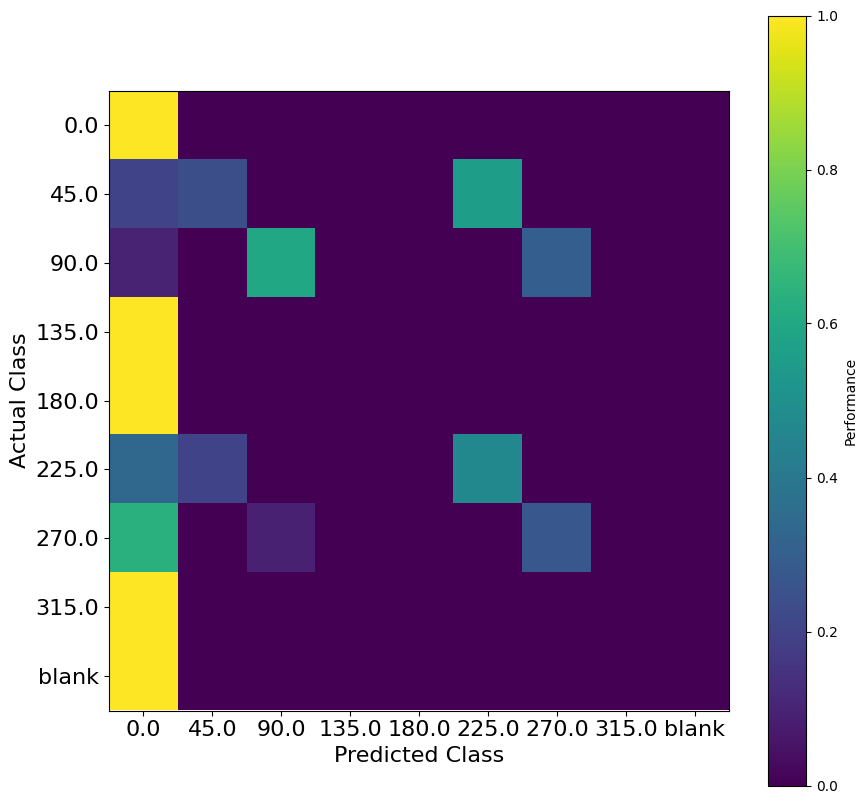

In [70]:
orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']

def plot_confusion_matrix(stim_test, stim_test_predicted, labels):
    C = confusion_matrix(stim_test, stim_test_predicted, normalize = 'true', labels=labels)
    # Note that normalization is needed when all classes are not of the same size
    # The default is to plot based on counts

    num_classes = len(labels)

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111)
    cax = ax.imshow(C,interpolation='none', vmin=0, vmax=C.max())

    ax.set_xlabel('Predicted Class', fontsize=16)
    ax.set_ylabel('Actual Class', fontsize=16)

    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(labels, fontsize=16)

    ax.set_yticks(range(num_classes))
    ax.set_yticklabels(labels, fontsize=16)

    cbar = plt.colorbar(cax)
    cbar.set_label('Performance')

plot_confusion_matrix(stim_ori_test, stim_ori_test_predicted, orientation_labels)

**Exercise 4**:  Plot the temporal frequency confusion matrix

In [ ]:
tf_labels = [str(tf) for tf in temporal_frequencies[:-1]] + ['blank']



The weights for the classifier are stored in a property called `coef_`.  Sadly, they are in arbitrary order so we have to do some rearranging to make them more interpretable.


In [71]:
def plot_weights_and_tuning_curves(classifier, tuning_curves, stim_values, stim_label):
    weights = classifier.coef_
    weights.shape

    classes = np.array([float(c) if c!='blank' else np.nan for c in classifier.classes_])
    class_index = np.argsort(classes)
    classes[class_index]

    fig, ax = plt.subplots(1,2, figsize=(10,5))

    ax[0].plot(classes[class_index[:-1]], weights[class_index[:-1],0], 'o-', label='cell index '+str(cell_index))
    ax[0].plot(classes[class_index[:-1]], weights[class_index[:-1],1], 'o-', label='cell index '+str(cell_index2))
    ax[0].set_xticks(classes[class_index[:-1]])
    ax[0].legend()
    ax[0].set_ylabel('weight')
    ax[0].set_xlabel('class name')
    ax[0].set_title('Classifier Weights')

    ax[1].plot(stim_values[:-1], tuning_curves[cell_index],'o-', label='cell index '+str(cell_index))
    ax[1].plot(stim_values[:-1], tuning_curves[cell_index2],'o-', label='cell index '+str(cell_index2))
    ax[1].legend()
    ax[1].set_xlabel(stim_label)
    ax[1].set_ylabel("Mean DF/F")
    ax[1].set_xticks(stim_values[:-1])
    ax[1].set_title('Tuning Curves')

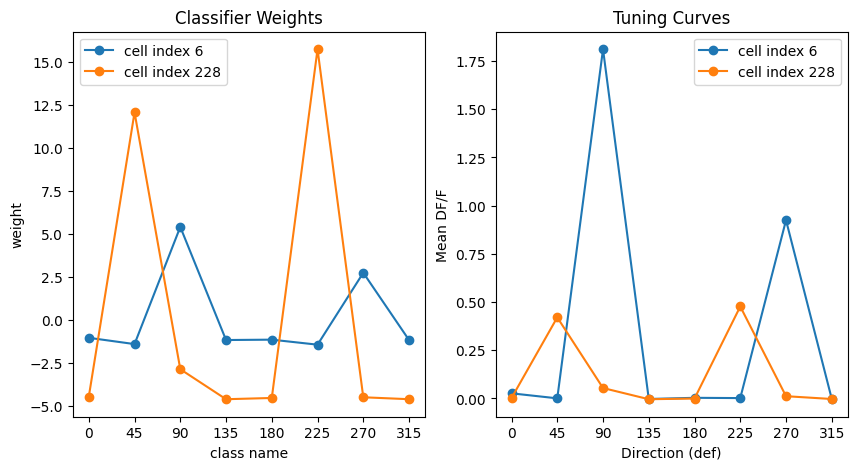

In [72]:
plot_weights_and_tuning_curves(classifier_ori, dg_tuning_curves, orientations, "Direction (def)")

**Exercise 5**:  Plot the weights for the temporal frequency decoder.  Do they look similar to the tuning curves?

Can we do better with all of the neurons?

In [73]:
test_index = int(0.75*num_trials)

response_test = response[test_index:]
response_train = response[:test_index]

stim_ori_test = stim_ori[test_index:]
stim_ori_train = stim_ori[:test_index]

(response_test.shape, stim_ori_test.shape), (response_train.shape, stim_ori_train.shape)

(((157, 290), (157,)), ((471, 290), (471,)))

In [74]:
all_neuron_classifier = LDA()
all_neuron_classifier.fit(response_train, stim_ori_train)

LinearDiscriminantAnalysis()

In [75]:
stim_ori_train_predicted = all_neuron_classifier.predict(response_train)
stim_ori_test_predicted = all_neuron_classifier.predict(response_test)

In [78]:
print("Percentage correct on training set:  ", np.mean(stim_ori_train_predicted == stim_ori_train))
print("Percentage correct on testing set:  ", np.mean(stim_ori_test_predicted == stim_ori_test))

Percentage correct on training set:   1.0
Percentage correct on testing set:   0.6496815286624203


How does this classifier perform on the training set!  What about the test set?  (If there is a difference, why?)

Where is the classifier making mistakes?

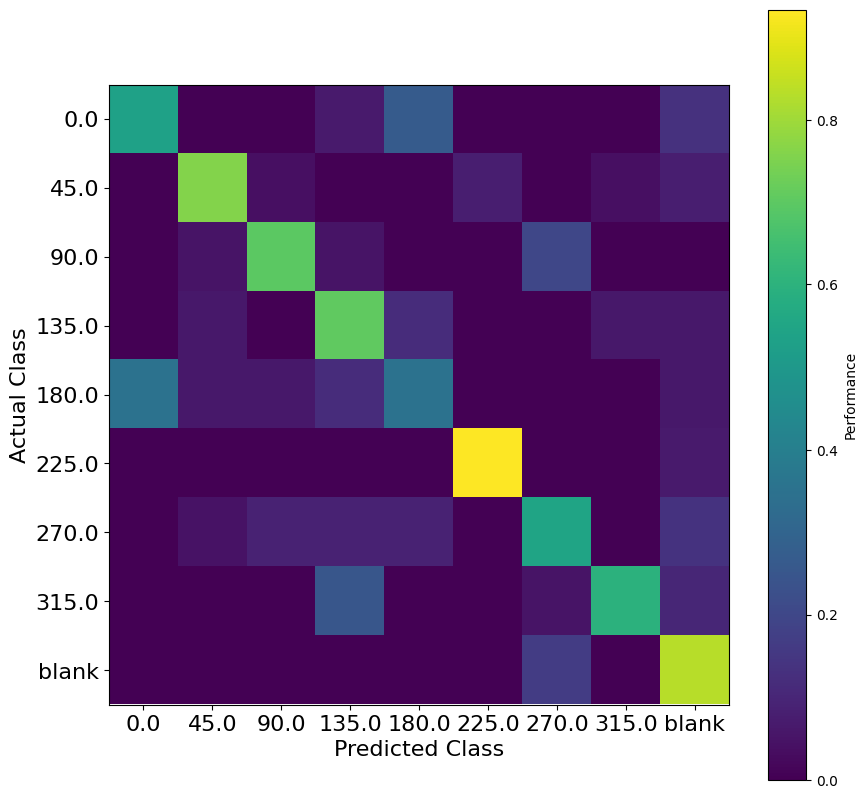

In [79]:
plot_confusion_matrix(stim_ori_test, stim_ori_test_predicted, orientation_labels)

We see adding neurons provides more information to the classifier.  How many neurons do we need for good accuracy?  One of the projects explores pushing this analysis further.

**Exercise 6**:  Decode temporal frequency with all the neurons and plot the confusion matrix.  How does this performance increase with number of neurons?

In [ ]:
stim_tf_test = stim_tf[test_index:]
stim_tf_train = stim_tf[:test_index]